# Simple Linear Regression:

- Simple linear regression is a statistical method for modeling the relationship between two continuous variables: a dependent (or response) variable and a single independent (or explanatory) variable.

- It finds the best-fitting straight line, known as the line of best fit or regression line, to describe how the independent variable predicts or influences the dependent variable. This line is represented by an equation 𝑌 = 𝛽0 + 𝛽1𝑋 + 𝜖, where 𝛽0 is the intercept, 𝛽1 is the slope, and 𝜖 is the error term. 

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.api import OLS

#### Example 1 (Using Linear Regression from Sklearn): 

In [2]:
df = pd.read_csv('50_Startups.csv')

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [8]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [9]:
# Dividing Data into Features (Independent Variables) and Target (Dependent Variable):

X = df[['R&D Spend']]
y = df['Profit']

In [11]:
X.head()

,R&D Spend
0,165349.20
1,162597.70
2,153441.51
3,144372.41
4,142107.34


In [12]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [15]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 1)
(10, 1)
(40,)
(10,)


In [17]:
# Feature Scaling:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train

array([[ 0.34202149],
       [ 1.36207849],
       [-0.71081297],
       [ 0.90611438],
       [ 1.40997088],
       [ 1.20367103],
       [-1.05285826],
       [-1.61480906],
       [-1.642623  ],
       [ 0.77885123],
       [ 0.96515572],
       [ 0.00687736],
       [-0.01361318],
       [-0.66099544],
       [-0.34996231],
       [ 1.85350175],
       [-1.17369938],
       [-0.11798808],
       [-0.46926521],
       [ 1.14576723],
       [-0.25546817],
       [ 0.48597351],
       [-1.03655971],
       [ 1.79532434],
       [ 0.01483507],
       [ 1.6017269 ],
       [-1.3147716 ],
       [-0.66970778],
       [-0.21472284],
       [-1.03464471],
       [ 0.51221561],
       [-0.07809041],
       [ 0.29731084],
       [-1.642623  ],
       [-0.03032003],
       [ 1.11238589],
       [-1.14276186],
       [ 0.89344327],
       [-0.24603715],
       [-1.21489084]])

In [19]:
X_test

array([[ 0.30245367],
       [-0.82734624],
       [-0.33181874],
       [-1.62147425],
       [ 0.35879726],
       [-1.63116196],
       [-0.04987791],
       [-0.2753597 ],
       [-0.30191325],
       [ 0.18462534]])

In [20]:
# Creating Linear Regression Model:

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Predictions of Test Data:

y_pred = lr.predict(X_test)
y_pred

array([127862.20996405,  82250.56334619, 102255.72078164,  50190.4734756 ,
       130136.88190548,  49799.36685472, 113638.0775288 , 104535.0534288 ,
       103463.04843113, 123105.31102669])

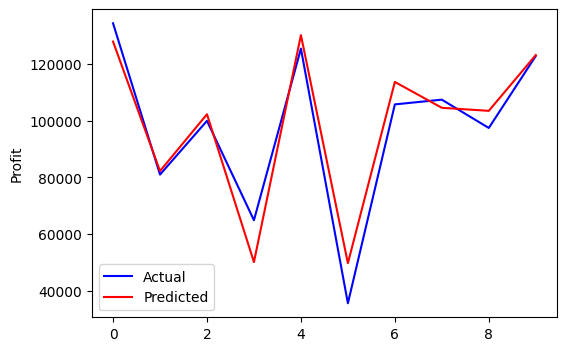

In [32]:
# Plotting Actual Test Data (y_test) vs Model Predictions (y_pred):

plt.figure(figsize= (6,4))
sns.lineplot(x= range(len(y_test)), y= y_test, color= 'blue', label= 'Actual')
sns.lineplot(x= range(len(y_test)), y= y_pred, color= 'red', label= 'Predicted')
plt.legend()
plt.show()

In [33]:
# Model Evaluation:

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

MAE: 6077.363300620399
MSE: 59510962.80787997
RMSE: 7714.334890830185
R2-Score: 0.9265108109341951


#### Example 2 (USING OLS From Statsmodels):

In [53]:
df = pd.read_csv('Advertising.csv')

In [54]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [55]:
df = df.drop('Unnamed: 0', axis= 1)

In [56]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [58]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [59]:
# Dividing Data into Features (Independent Variables) and Target (Dependent Variable):

X = df[['TV']]
y = df['sales']

In [60]:
X.head()

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8


In [61]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [62]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [63]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [67]:
# Creating Linear Regression Model Using Ordinary Least Squares (OLS):

lr_ols = OLS(y_train, X_train)
lr_ols = lr_ols.fit()
lr_ols

In [68]:
lr_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  sales   R-squared (uncentered):                   0.899
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              1413.
Date:                Fri, 10 Oct 2025   Prob (F-statistic):                    5.29e-81
Time:                        19:01:08   Log-Likelihood:                         -476.95
No. Observations:                 160   AIC:                                      955.9
Df Residuals:                     159   BIC:                                      959.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
TV             0.0826      0.002     37.586      0.000       0.078       0.087
==============================================================================
Omnibus:                       16.124   Durbin-Watson:                   1.842
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.460
Skew:                          -0.830   Prob(JB):                     9.80e-05
Kurtosis:                       3.113   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""